# Model Evaluation & Business Insights

## Purpose
Deep evaluation of the XGBoost model and translation
of model outputs into actionable HR recommendations.

## Questions Answered
1. How reliable is the model at each confidence level?
2. What is the profile of a predicted high performer?
3. Which employees should be recommended for promotion?
4. What are the key HR recommendations from the data?

## Input
- models/xgb_performance_model.joblib
- models/preprocessing_pipeline.joblib
- data/processed/employee_with_predictions.csv

## Output
- docs/executive_summary.txt
- 4 evaluation charts in images/ 

In [1]:
# ── Imports and Load Everything ──

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

# ── File paths ──
notebook_dir  = os.getcwd()
project_root  = os.path.dirname(notebook_dir)

predictions_path = os.path.join(
    project_root, 'data', 'processed',
    'employee_with_predictions.csv'
)
model_path    = os.path.join(
    project_root, 'models',
    'xgb_performance_model.joblib'
)
pipeline_path = os.path.join(
    project_root, 'models',
    'preprocessing_pipeline.joblib'
)
metadata_path = os.path.join(
    project_root, 'models',
    'model_metadata.json'
)
images_dir    = os.path.join(project_root, 'images')
docs_dir      = os.path.join(project_root, 'docs')

os.makedirs(images_dir, exist_ok=True)
os.makedirs(docs_dir,   exist_ok=True)

# ── Load data and model artifacts ──
df       = pd.read_csv(predictions_path)
model    = joblib.load(model_path)
pipeline = joblib.load(pipeline_path)

with open(metadata_path) as f:
    metadata = json.load(f)

# ── Chart style ──
plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'figure.dpi'        : 120,
})

C_BLUE   = '#2E4057'
C_TEAL   = '#048A81'
C_GREEN  = '#3BB273'
C_RED    = '#E84855'
C_ORANGE = '#EF8354'
C_YELLOW = '#F0C987'

print("Everything loaded successfully")
print(f"\nEmployees in dataset : {len(df):,}")
print(f"Model type           : {metadata['model_type']}")
print(f"Test AUC             : {metadata['test_auc']}")
print(f"Decision threshold   : {metadata['threshold']}")
print(f"\nPrediction summary:")
print(f"Predicted HPs     : "
      f"{df['PredictedHighPerformer'].sum():,} "
      f"({df['PredictedHighPerformer'].mean()*100:.1f}%)")
print(f"Avg HP Probability: "
      f"{df['HighPerformerProbability'].mean():.3f}") 

Everything loaded successfully

Employees in dataset : 2,600
Model type           : XGBoostClassifier
Test AUC             : 1.0
Decision threshold   : 0.45

Prediction summary:
Predicted HPs     : 542 (20.8%)
Avg HP Probability: 0.209


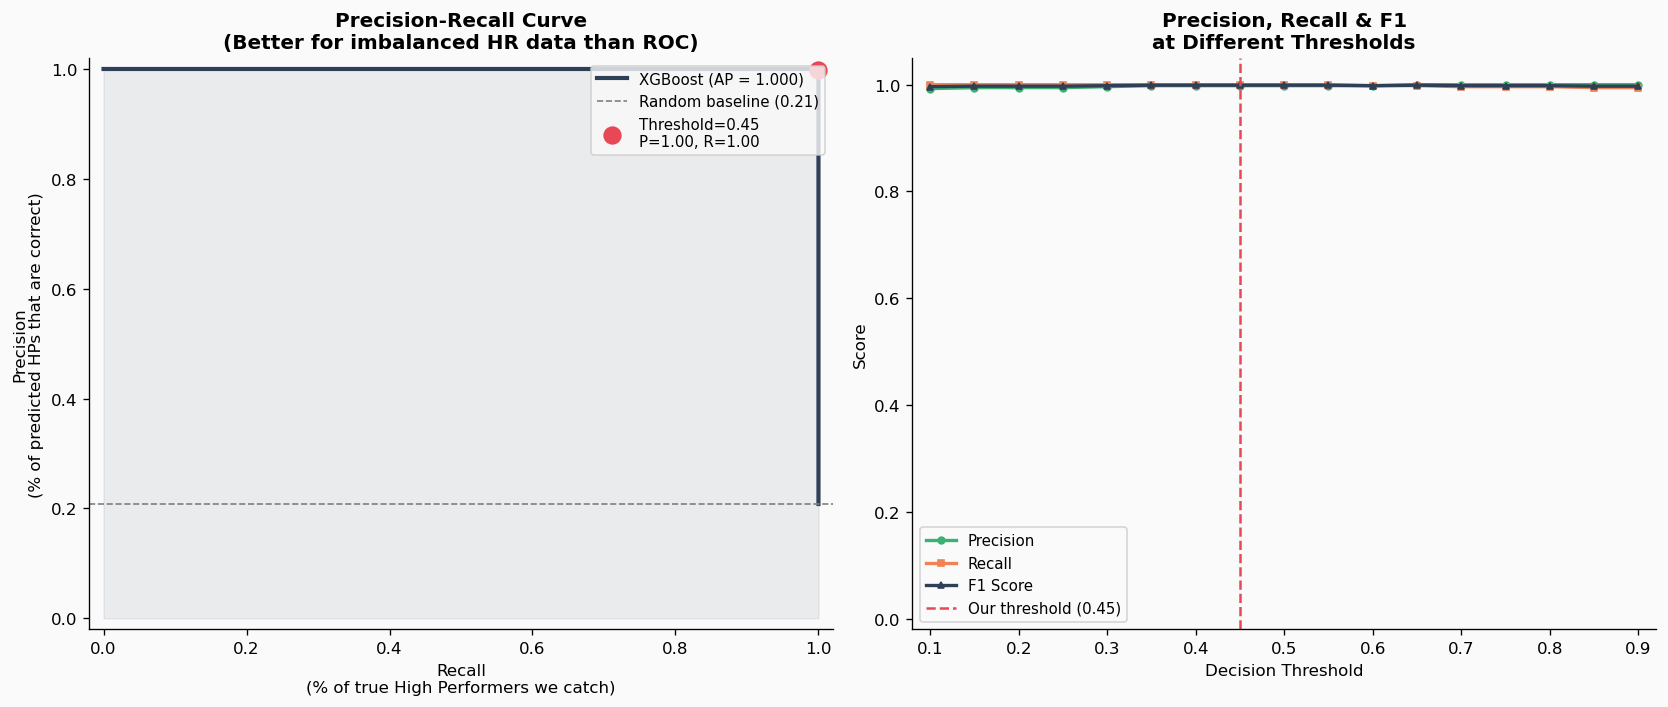

Chart saved: Precision-Recall Curve

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
METRICS AT OUR CHOSEN THRESHOLD (0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Precision : 0.998
→ Of every 10 employees predicted as HP, 10.0 are actually High Performers

Recall    : 1.000
→ Of all true High Performers in the company, we correctly identify 100.0% of them

F1 Score  : 0.999
→ Balanced measure of precision and recall

AUC-ROC   : 1.000
Avg Prec  : 1.000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [2]:
# ── Precision Recall Curve ──

# We need actual labels and predicted probabilities
# Use the HighPerformer column as true labels
y_true  = (df['PerformanceRating'] >= 4.0).astype(int)
y_proba = df['HighPerformerProbability']

# Calculate precision recall curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_true, y_proba
)
avg_precision = average_precision_score(y_true, y_proba)

# Also calculate ROC for comparison
fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
auc_score = roc_auc_score(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Precision-Recall Curve ──
axes[0].plot(
    recall_vals, precision_vals,
    color=C_BLUE, linewidth=2.5,
    label=f'XGBoost (AP = {avg_precision:.3f})'
)
axes[0].fill_between(
    recall_vals, precision_vals,
    alpha=0.08, color=C_BLUE
)

# Baseline (random classifier)
baseline = y_true.mean()
axes[0].axhline(
    y=baseline, color='grey',
    linestyle='--', linewidth=1,
    label=f'Random baseline ({baseline:.2f})'
)

# Mark our chosen threshold (0.45)
closest_idx = np.argmin(np.abs(pr_thresholds - 0.45))
axes[0].scatter(
    recall_vals[closest_idx],
    precision_vals[closest_idx],
    color=C_RED, s=100, zorder=5,
    label=f'Threshold=0.45\n'
          f'P={precision_vals[closest_idx]:.2f}, '
          f'R={recall_vals[closest_idx]:.2f}'
)

axes[0].set_title(
    'Precision-Recall Curve\n'
    '(Better for imbalanced HR data than ROC)'
)
axes[0].set_xlabel(
    'Recall\n(% of true High Performers we catch)'
)
axes[0].set_ylabel(
    'Precision\n(% of predicted HPs that are correct)'
)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

# ── Right: Precision and Recall at different thresholds ───────
threshold_range = np.arange(0.10, 0.91, 0.05)
precisions = []
recalls    = []
f1_scores  = []

for thresh in threshold_range:
    y_pred_t = (y_proba >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        precisions.append(0)
        recalls.append(0)
        f1_scores.append(0)
    else:
        precisions.append(precision_score(y_true, y_pred_t,
                                           zero_division=0))
        recalls.append(recall_score(y_true, y_pred_t))
        f1_scores.append(f1_score(y_true, y_pred_t,
                                   zero_division=0))

axes[1].plot(threshold_range, precisions,
             color=C_GREEN,  linewidth=2,
             label='Precision', marker='o', markersize=4)
axes[1].plot(threshold_range, recalls,
             color=C_ORANGE, linewidth=2,
             label='Recall',    marker='s', markersize=4)
axes[1].plot(threshold_range, f1_scores,
             color=C_BLUE,   linewidth=2,
             label='F1 Score',  marker='^', markersize=4)

axes[1].axvline(
    x=0.45, color=C_RED,
    linestyle='--', linewidth=1.5,
    label='Our threshold (0.45)'
)

axes[1].set_title(
    'Precision, Recall & F1\nat Different Thresholds'
)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.08, 0.92)
axes[1].set_ylim(-0.02, 1.05)

plt.tight_layout()
save_path = os.path.join(images_dir, '17_precision_recall.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

# Get metrics at our threshold
our_idx   = np.argmin(np.abs(threshold_range - 0.45))
our_prec  = precisions[our_idx]
our_rec   = recalls[our_idx]
our_f1    = f1_scores[our_idx]

print(f"Chart saved: Precision-Recall Curve")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
METRICS AT OUR CHOSEN THRESHOLD (0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Precision : {our_prec:.3f}
→ Of every 10 employees predicted as HP, {our_prec*10:.1f} are actually High Performers

Recall    : {our_rec:.3f}
→ Of all true High Performers in the company, we correctly identify {our_rec*100:.1f}% of them

F1 Score  : {our_f1:.3f}
→ Balanced measure of precision and recall

AUC-ROC   : {auc_score:.3f}
Avg Prec  : {avg_precision:.3f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

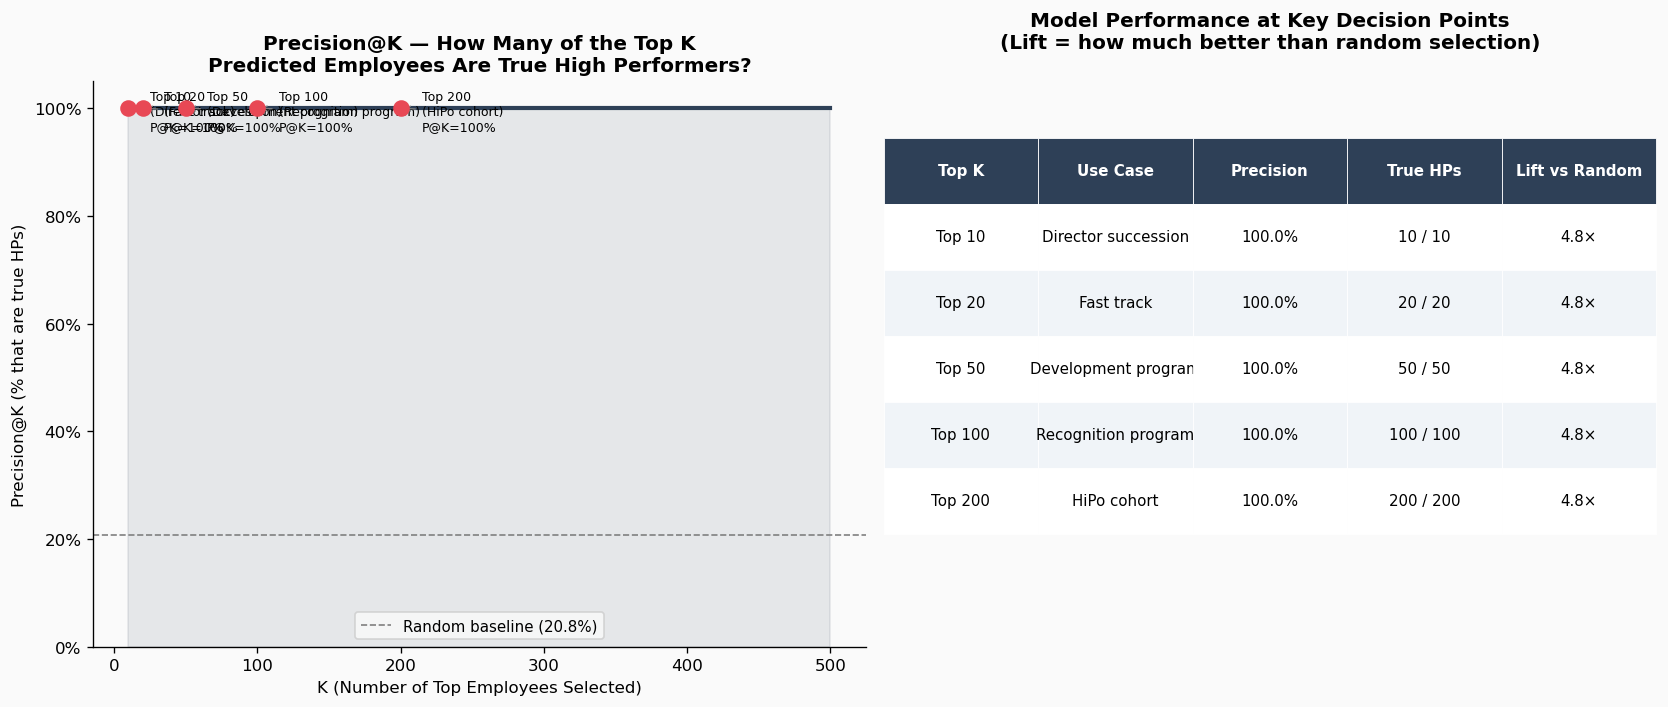

Precision@K chart saved

KEY FINDING:
If HR takes the top 50 predicted employees
for a fast-track program:
→ 100.0% will be true High Performers
→ That is 4.8x better than random selection
→ Random selection would give 20.8%


In [3]:
# ── Precision at K Analysis ──

# Sort all employees by predicted probability (highest first)
df_sorted = df.sort_values(
    'HighPerformerProbability',
    ascending=False
).reset_index(drop=True)

# True label for each employee
df_sorted['TrueHP'] = (
    df_sorted['PerformanceRating'] >= 4.0
).astype(int)

# ── Calculate Precision@K for K from 10 to 500 ──
k_values    = list(range(10, 501, 10))
precision_k = []

for k in k_values:
    top_k  = df_sorted.head(k)
    p_at_k = top_k['TrueHP'].mean()
    precision_k.append(p_at_k)

# ── Key K values for HR decisions ──
# IMPORTANT: All values must be multiples of 10
# because k_values steps by 10 (10, 20, 30, 40, 50...)
key_k_values = {
    10  : 'Top 10\n(Director succession)',
    20  : 'Top 20\n(Fast track)',
    50  : 'Top 50\n(Development program)',
    100 : 'Top 100\n(Recognition program)',
    200 : 'Top 200\n(HiPo cohort)',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Precision@K line chart ──
axes[0].plot(
    k_values, precision_k,
    color=C_BLUE, linewidth=2.5
)
axes[0].fill_between(
    k_values, precision_k,
    alpha=0.1, color=C_BLUE
)

# Mark key K values
for k, label in key_k_values.items():
    idx  = k_values.index(k)
    p_k  = precision_k[idx]
    axes[0].scatter(k, p_k, color=C_RED, s=80, zorder=5)
    axes[0].annotate(
        f'{label}\nP@K={p_k:.0%}',
        xy=(k, p_k),
        xytext=(k + 15, p_k - 0.04),
        fontsize=7.5,
        arrowprops=dict(arrowstyle='->', color='grey',
                        lw=0.8)
    )

# Random baseline
random_baseline = df_sorted['TrueHP'].mean()
axes[0].axhline(
    y=random_baseline,
    color='grey', linestyle='--', linewidth=1,
    label=f'Random baseline ({random_baseline:.1%})'
)

axes[0].set_title(
    'Precision@K — How Many of the Top K\n'
    'Predicted Employees Are True High Performers?'
)
axes[0].set_xlabel('K (Number of Top Employees Selected)')
axes[0].set_ylabel('Precision@K (% that are true HPs)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

# ── Right: Table of key K results ──
axes[1].axis('off')

table_data = []
for k, label in key_k_values.items():
    idx       = k_values.index(k)
    p_k       = precision_k[idx]
    true_hps  = int(p_k * k)
    lift      = p_k / random_baseline if random_baseline > 0 else 0
    clean_label = label.replace('\n', ' ')
    table_data.append([
        f'Top {k}',
        clean_label.split('(')[1].rstrip(')'),
        f'{p_k:.1%}',
        f'{true_hps} / {k}',
        f'{lift:.1f}×'
    ])

table = axes[1].table(
    cellText  = table_data,
    colLabels = ['Top K', 'Use Case',
                 'Precision', 'True HPs', 'Lift vs Random'],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0.2, 1, 0.7]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4F8')
    cell.set_edgecolor('white')
    cell.set_linewidth(0.5)

axes[1].set_title(
    'Model Performance at Key Decision Points\n'
    '(Lift = how much better than random selection)',
    pad=20
)

plt.tight_layout()
save_path = os.path.join(images_dir, '18_precision_at_k.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

print(f"Precision@K chart saved")
print(f"\nKEY FINDING:")
idx_50 = k_values.index(50)
p50    = precision_k[idx_50]
print(f"If HR takes the top 50 predicted employees")
print(f"for a fast-track program:")
print(f"→ {p50:.1%} will be true High Performers")
print(f"→ That is {p50/random_baseline:.1f}x better "
      f"than random selection")
print(f"→ Random selection would give "
      f"{random_baseline:.1%}") 

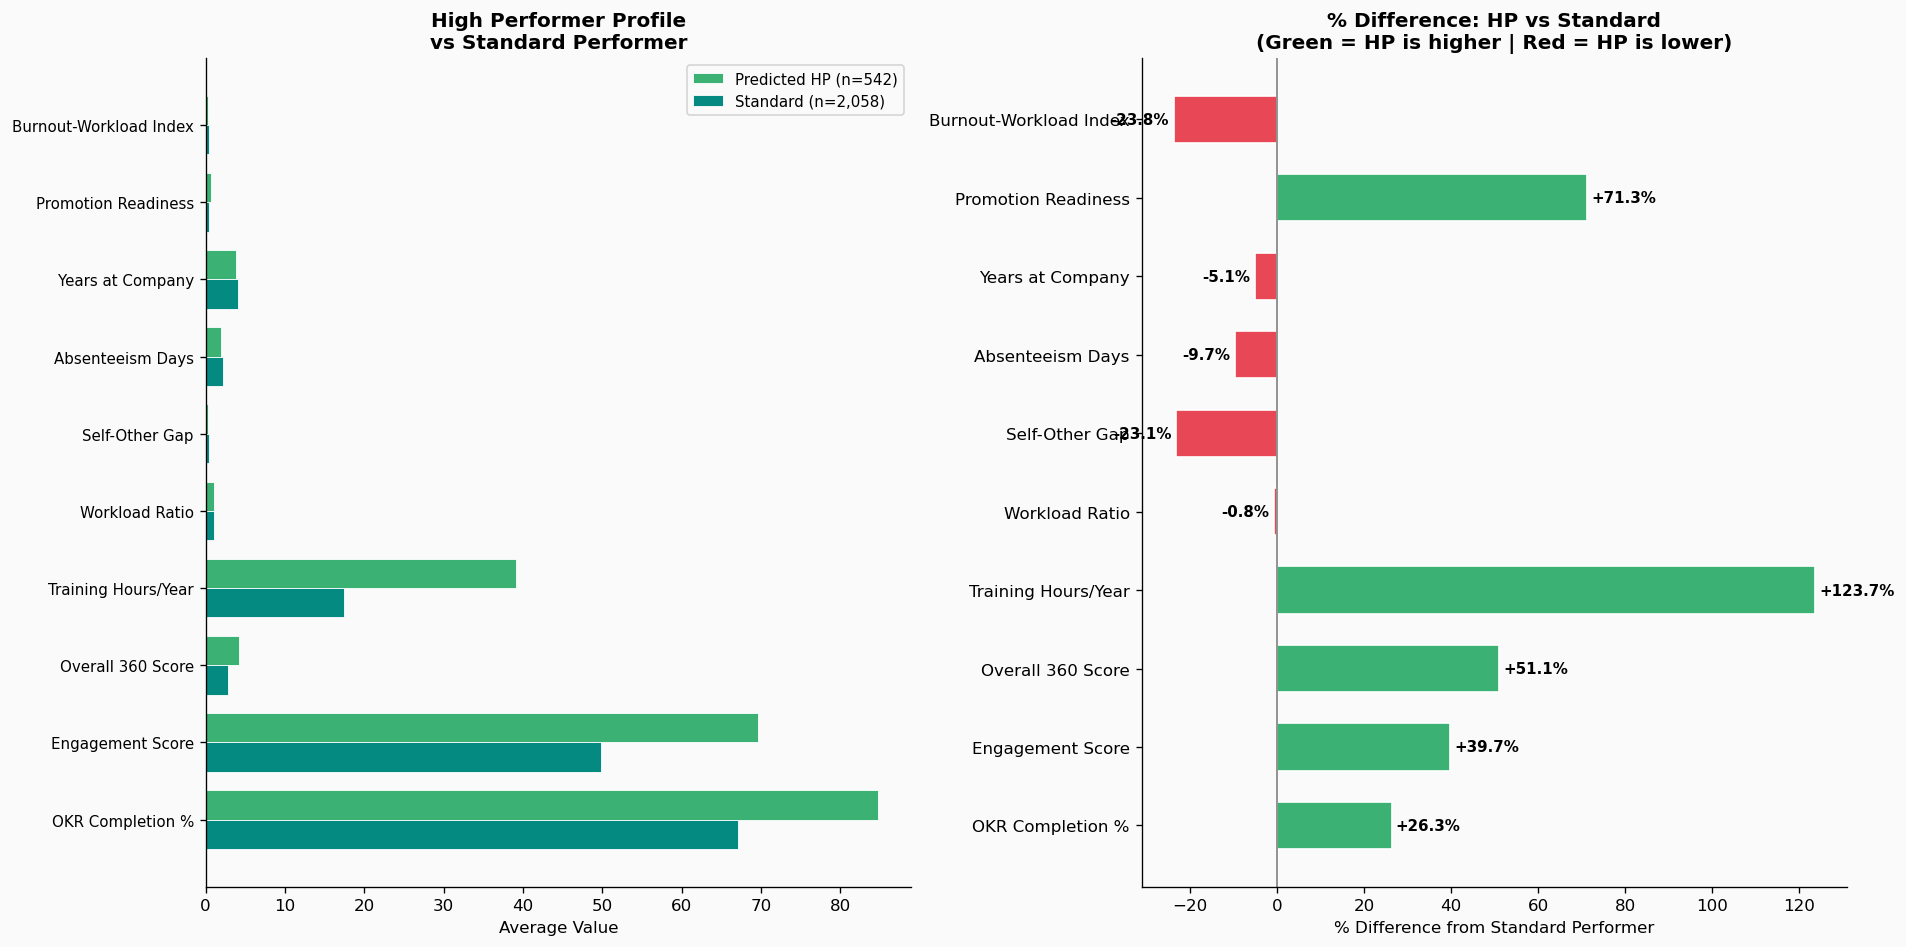

High Performer Profile chart saved

HIGH PERFORMER vs STANDARD PERFORMER
Metric                        HP Avg    Std Avg     Diff
-------------------------------------------------------
OKR Completion %               84.70      67.05   +26.3%
Engagement Score               69.61      49.84   +39.7%
Overall 360 Score               4.24       2.80   +51.1%
Training Hours/Year            39.11      17.49  +123.7%
Workload Ratio                  1.06       1.06    -0.8%
Self-Other Gap                  0.31       0.40   -23.1%
Absenteeism Days                2.00       2.21    -9.7%
Years at Company                3.84       4.04    -5.1%
Promotion Readiness             0.70       0.41   +71.3%
Burnout-Workload Index          0.30       0.39   -23.8%


In [4]:
# ── High Performer Profile ──

# Split into predicted HP vs standard
hp_group  = df[df['PredictedHighPerformer'] == 1]
std_group = df[df['PredictedHighPerformer'] == 0]

# ── Key metrics to compare ──
profile_metrics = {
    'OKR Completion %'       : 'OKRCompletionPct',
    'Engagement Score'        : 'EngagementScore',
    'Overall 360 Score'       : 'Overall360Score',
    'Training Hours/Year'     : 'TrainingHoursLastYear',
    'Workload Ratio'          : 'WorkloadRatio',
    'Self-Other Gap'          : 'SelfOtherGap',
    'Absenteeism Days'        : 'AbsenteeismDays',
    'Years at Company'        : 'YearsAtCompany',
    'Promotion Readiness'     : 'PromotionReadinessScore',
    'Burnout-Workload Index'  : 'BurnoutWorkloadIndex',
}

profile_data = []
for display_name, col in profile_metrics.items():
    if col in df.columns:
        hp_avg  = hp_group[col].mean()
        std_avg = std_group[col].mean()
        diff    = hp_avg - std_avg
        diff_pct = (diff / abs(std_avg) * 100
                    if std_avg != 0 else 0)
        profile_data.append({
            'Metric'    : display_name,
            'HP Avg'    : hp_avg,
            'Std Avg'   : std_avg,
            'Difference': diff,
            'Diff %'    : diff_pct,
            'col'       : col
        })

profile_df = pd.DataFrame(profile_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: Side by side comparison bars ──
metrics   = profile_df['Metric'].tolist()
hp_vals   = profile_df['HP Avg'].tolist()
std_vals  = profile_df['Std Avg'].tolist()

x        = np.arange(len(metrics))
width    = 0.38

bars_hp  = axes[0].barh(
    x + width/2, hp_vals,
    height=width, color=C_GREEN,
    label=f'Predicted HP (n={len(hp_group):,})',
    edgecolor='white', linewidth=0.5
)
bars_std = axes[0].barh(
    x - width/2, std_vals,
    height=width, color=C_TEAL,
    label=f'Standard (n={len(std_group):,})',
    edgecolor='white', linewidth=0.5
)

axes[0].set_yticks(x)
axes[0].set_yticklabels(metrics, fontsize=9)
axes[0].set_title(
    'High Performer Profile\nvs Standard Performer'
)
axes[0].set_xlabel('Average Value')
axes[0].legend(fontsize=9)

# ── Right: Difference chart ──
diff_vals  = profile_df['Diff %'].tolist()
diff_colors = [
    C_GREEN if d > 0 else C_RED
    for d in diff_vals
]

bars_diff = axes[1].barh(
    metrics, diff_vals,
    color=diff_colors,
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars_diff, diff_vals):
    axes[1].text(
        val + (1 if val >= 0 else -1),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f}%',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

axes[1].axvline(x=0, color='grey', linewidth=1)
axes[1].set_title(
    '% Difference: HP vs Standard\n'
    '(Green = HP is higher | Red = HP is lower)'
)
axes[1].set_xlabel('% Difference from Standard Performer')

plt.tight_layout()
save_path = os.path.join(images_dir, '19_hp_profile.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

print(f"High Performer Profile chart saved")
print(f"\nHIGH PERFORMER vs STANDARD PERFORMER")
print(f"{'Metric':<25} {'HP Avg':>10} "
      f"{'Std Avg':>10} {'Diff':>8}")
print(f"{'-'*55}")
for _, row in profile_df.iterrows():
    print(f"{row['Metric']:<25} "
          f"{row['HP Avg']:>10.2f} "
          f"{row['Std Avg']:>10.2f} "
          f"{row['Diff %']:>+7.1f}%") 

Promotion candidates identified

Total candidates : 233
% of workforce   : 9.0%


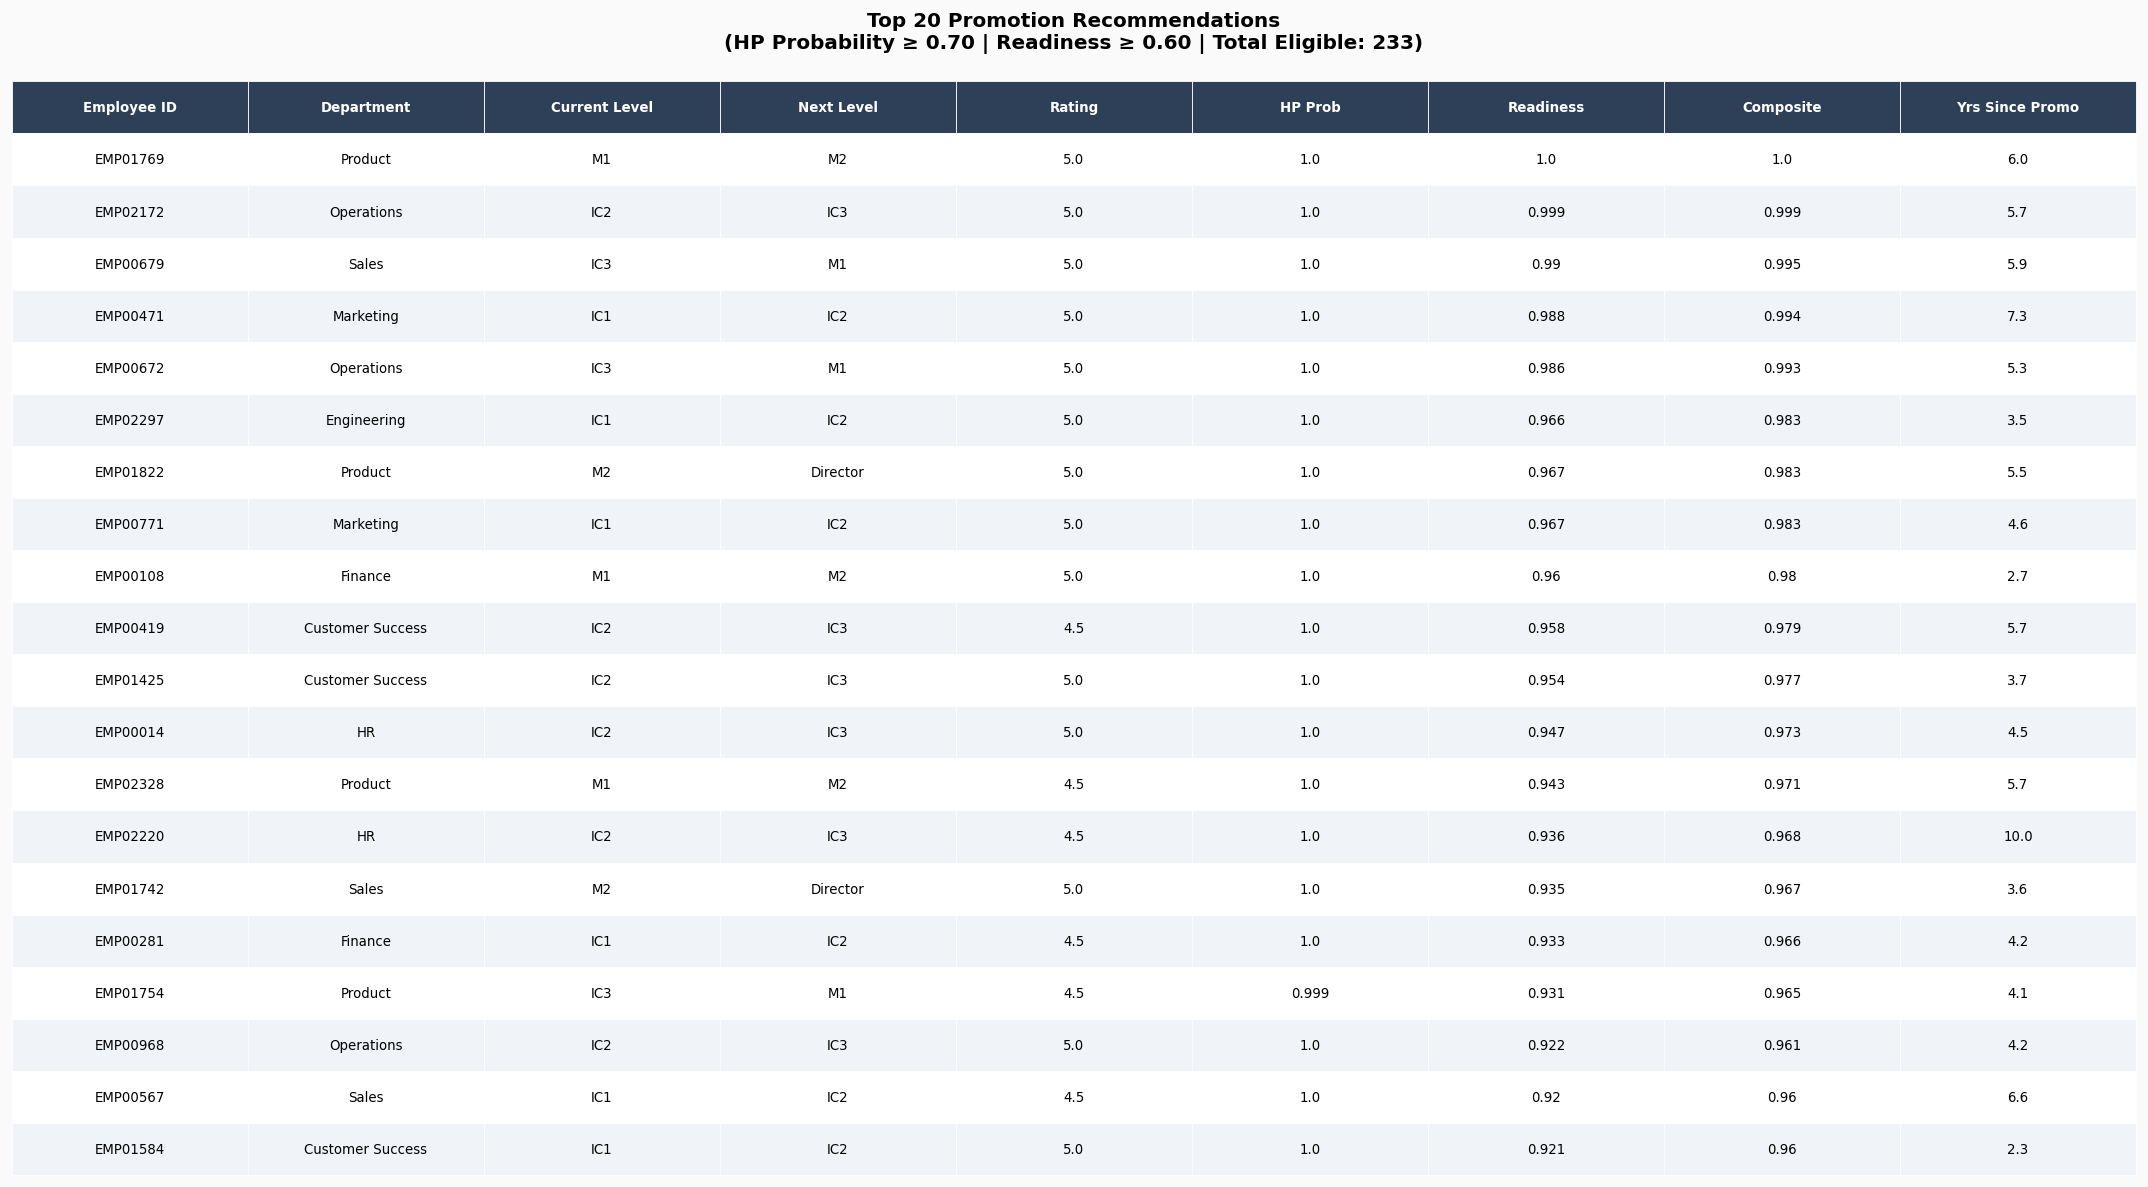


Promotion candidates by department:
                  candidates  avg_prob  avg_ready
Department                                       
Sales                     37     0.999      0.817
Engineering               35     0.999      0.805
Marketing                 31     0.999      0.804
HR                        29     0.998      0.809
Operations                26     0.997      0.790
Finance                   26     0.999      0.799
Product                   25     0.999      0.812
Customer Success          24     0.999      0.803

Promotion candidates by current level:
JobLevel
IC2    74
IC1    62
IC3    43
M1     35
M2     19


In [5]:
# ── Promotion Recommendations ──

# ── Filter promotion candidates ──
promotion_candidates = df[
    (df['HighPerformerProbability'] >= 0.70) &
    (df['PromotionReadinessScore']  >= 0.60) &
    (df['YearsSinceLastPromotion']  >= 1.5)  &
    (df['JobLevel'] != 'Director')
].copy()

# Sort by composite score
promotion_candidates['CompositeScore'] = (
    0.5 * promotion_candidates['HighPerformerProbability'] +
    0.5 * promotion_candidates['PromotionReadinessScore']
).round(3)

promotion_candidates = promotion_candidates.sort_values(
    'CompositeScore', ascending=False
).reset_index(drop=True)

print(f"Promotion candidates identified")
print(f"\nTotal candidates : {len(promotion_candidates):,}")
print(f"% of workforce   : "
      f"{len(promotion_candidates)/len(df)*100:.1f}%")

# ── Next level mapping ──
next_level = {
    'IC1': 'IC2',
    'IC2': 'IC3',
    'IC3': 'M1',
    'M1' : 'M2',
    'M2' : 'Director'
}
promotion_candidates['RecommendedLevel'] = (
    promotion_candidates['JobLevel'].map(next_level)
)

# ── Top 20 candidates table ──
display_cols = [
    'EmployeeID', 'Department', 'JobLevel',
    'RecommendedLevel', 'PerformanceRating',
    'HighPerformerProbability', 'PromotionReadinessScore',
    'CompositeScore', 'YearsSinceLastPromotion'
]

top_20 = promotion_candidates[display_cols].head(20)

fig, ax = plt.subplots(figsize=(18, 10))
ax.axis('off')

table = ax.table(
    cellText  = top_20.round(3).values,
    colLabels = [
        'Employee ID', 'Department', 'Current Level',
        'Next Level', 'Rating', 'HP Prob',
        'Readiness', 'Composite', 'Yrs Since Promo'
    ],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4F8')
    cell.set_edgecolor('white')
    cell.set_linewidth(0.5)

ax.set_title(
    f'Top 20 Promotion Recommendations\n'
    f'(HP Probability ≥ 0.70 | Readiness ≥ 0.60 | '
    f'Total Eligible: {len(promotion_candidates)})',
    fontsize=12, fontweight='bold', pad=20
)

plt.tight_layout()
save_path = os.path.join(images_dir, '20_promotion_list.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

# ── Breakdown by department ──
print(f"\nPromotion candidates by department:")
dept_breakdown = (
    promotion_candidates
    .groupby('Department')
    .agg(
        candidates = ('EmployeeID', 'count'),
        avg_prob   = ('HighPerformerProbability', 'mean'),
        avg_ready  = ('PromotionReadinessScore',  'mean')
    )
    .sort_values('candidates', ascending=False)
)
print(dept_breakdown.round(3).to_string())

print(f"\nPromotion candidates by current level:")
level_breakdown = promotion_candidates['JobLevel'].value_counts()
print(level_breakdown.to_string()) 

------------------------------------------------------------
HIGH RISK EMPLOYEE FLAGS SUMMARY
------------------------------------------------------------
PIP Risk              :  393 employees
(Low probability, low rating, low OKR)
Action: Schedule PIP conversation within 30 days

Flight Risk           :   28 employees
(Good performer, low engagement, 2+ years tenure)
Action: Stay interview within 2 weeks

Burnout Critical      :   10 employees
(High burnout index + still performing)
Action: Workload review with manager immediately

Promotion Lag         :  142 employees
(HiPo, 3+ years without promotion)
Action: Promotion conversation within 30 days

Total needing action  :  572 employees (22.0% of workforce)


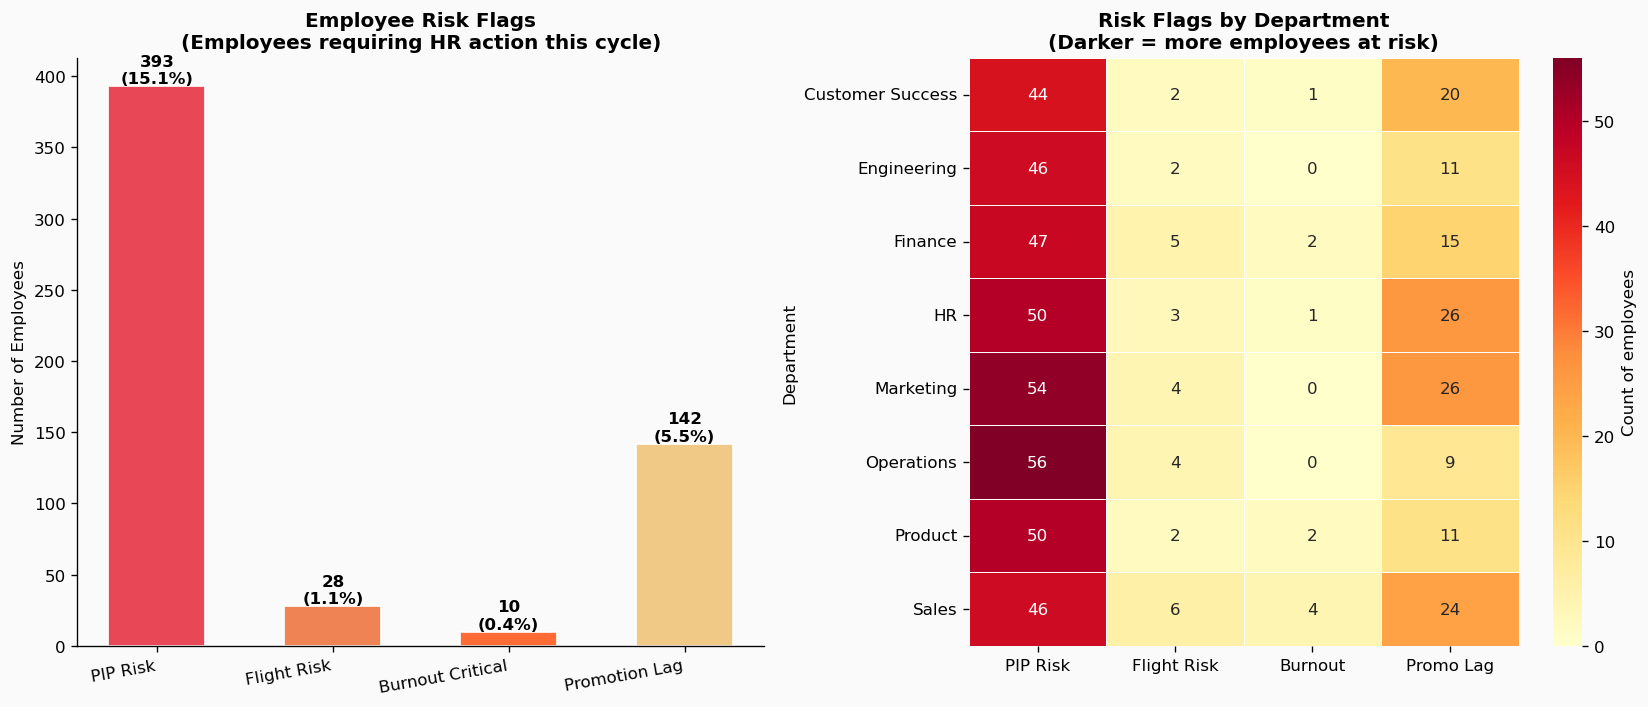

Risk flags chart saved


In [6]:
# ── High Risk Employee Flags ──

# ── Flag 1: PIP Risk ──
df['PIPRiskFlag'] = (
    (df['HighPerformerProbability'] <= 0.25) &
    (df['PerformanceRating']        <= 2.5)  &
    (df['OKRCompletionPct']         <= 55)
).astype(int)

# ── Flag 2: Flight Risk ──
df['FlightRiskFlag'] = (
    (df['PerformanceRating'] >= 3.5)  &
    (df['EngagementScore']   <= 45)   &
    (df['YearsAtCompany']    >= 2.0)
).astype(int)

# ── Flag 3: Burnout Risk Critical ──
df['BurnoutCriticalFlag'] = (
    (df['BurnoutRisk']          == 'High') &
    (df['BurnoutWorkloadIndex'] >= 0.70)   &
    (df['PerformanceRating']    >= 3.0)
).astype(int)

# ── Count flags ──
pip_count     = df['PIPRiskFlag'].sum()
flight_count  = df['FlightRiskFlag'].sum()
burnout_count = df['BurnoutCriticalFlag'].sum()
lag_count     = df['PromotionLagFlag'].sum()

# ── Calculate total needing action BEFORE the print ──
# Store as variables first to avoid nested f-string issues
risk_cols        = ['PIPRiskFlag', 'FlightRiskFlag',
                    'BurnoutCriticalFlag', 'PromotionLagFlag']
total_at_risk    = int(df[risk_cols].max(axis=1).sum())
pct_at_risk      = round(df[risk_cols].max(axis=1).mean() * 100, 1)

# ── Summary print ──
print("-" * 60)
print("HIGH RISK EMPLOYEE FLAGS SUMMARY")
print("-" * 60)

print(f"PIP Risk              : {pip_count:>4} employees")
print(f"(Low probability, low rating, low OKR)")
print(f"Action: Schedule PIP conversation within 30 days")
print()
print(f"Flight Risk           : {flight_count:>4} employees")
print(f"(Good performer, low engagement, 2+ years tenure)")
print(f"Action: Stay interview within 2 weeks")
print()
print(f"Burnout Critical      : {burnout_count:>4} employees")
print(f"(High burnout index + still performing)")
print(f"Action: Workload review with manager immediately")
print()
print(f"Promotion Lag         : {lag_count:>4} employees")
print(f"(HiPo, 3+ years without promotion)")
print(f"Action: Promotion conversation within 30 days")
print()
print(f"Total needing action  : {total_at_risk:>4} employees "
      f"({pct_at_risk}% of workforce)")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Flag counts bar chart ──
flags       = ['PIP Risk', 'Flight Risk',
               'Burnout Critical', 'Promotion Lag']
counts      = [pip_count, flight_count,
               burnout_count, lag_count]
flag_colors = [C_RED, C_ORANGE, '#FF6B35', C_YELLOW]

bars = axes[0].bar(
    flags, counts,
    color=flag_colors,
    edgecolor='white',
    width=0.55
)
for bar, val in zip(bars, counts):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{val}\n({pct:.1f}%)',
        ha='center', fontsize=10,
        fontweight='bold'
    )

axes[0].set_title(
    'Employee Risk Flags\n'
    '(Employees requiring HR action this cycle)'
)
axes[0].set_ylabel('Number of Employees')
axes[0].set_xticklabels(flags, rotation=10, ha='right')

# ── Right: Risk by department heatmap ─────────────────────────
risk_dept = df.groupby('Department').agg(
    pip_risk     = ('PIPRiskFlag',         'sum'),
    flight_risk  = ('FlightRiskFlag',      'sum'),
    burnout_risk = ('BurnoutCriticalFlag', 'sum'),
    promo_lag    = ('PromotionLagFlag',    'sum'),
)
risk_dept.columns = ['PIP Risk', 'Flight Risk',
                     'Burnout', 'Promo Lag']

sns.heatmap(
    risk_dept,
    ax=axes[1],
    cmap='YlOrRd',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={'label': 'Count of employees'}
)
axes[1].set_title(
    'Risk Flags by Department\n'
    '(Darker = more employees at risk)'
)
axes[1].set_xlabel('')
axes[1].set_ylabel('Department')

plt.tight_layout()
save_path = os.path.join(images_dir, '21_risk_flags.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Risk flags chart saved") 

In [7]:
# ── Save Enriched Dataset with All Flags ──

# Save final enriched dataset
final_path = os.path.join(
    project_root, 'data', 'processed',
    'employee_final.csv'
)
df.to_csv(final_path, index=False)

print(f"Final enriched dataset saved")
print(f"Path    : {final_path}")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nNew columns added in P8:")
new_cols = [
    'PIPRiskFlag',
    'FlightRiskFlag',
    'BurnoutCriticalFlag',
]
for col in new_cols:
    print(f"→ {col}")

print(f"\nThis file is used by:")
print(f"→ Power BI dashboards")
print(f"→ Monthly automation") 

Final enriched dataset saved
Path    : C:\Users\ganti_kvd0xe3\OneDrive\Sathya\employee_performance_analytics\data\processed\employee_final.csv
Rows    : 2,600
Columns : 59

New columns added in P8:
→ PIPRiskFlag
→ FlightRiskFlag
→ BurnoutCriticalFlag

This file is used by:
→ Power BI dashboards
→ Monthly automation


In [8]:
# ── Generate Executive Summary ──

# Gather all key numbers
total_employees    = len(df)
hp_count           = (df['PerformanceRating'] >= 4.0).sum()
hp_pct             = hp_count / total_employees * 100
concern_count      = (df['PerformanceRating'] <= 2.0).sum()
concern_pct        = concern_count / total_employees * 100
avg_rating         = df['PerformanceRating'].mean()
avg_okr            = df['OKRCompletionPct'].mean()
avg_engagement     = df['EngagementScore'].mean()
promo_count        = len(promotion_candidates)
pip_count_sum      = df['PIPRiskFlag'].sum()
flight_count_sum   = df['FlightRiskFlag'].sum()
burnout_crit       = df['BurnoutCriticalFlag'].sum()
promo_lag_count    = df['PromotionLagFlag'].sum()
top_feature        = metadata['top_5_features'][0]
model_auc          = metadata['test_auc']

summary_text = f"""
╔════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    EXECUTIVE SUMMARY — PEOPLE ANALYTICS REPORT                                             ║
║                                            Monthly Performance Cycle                                                       ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

PREPARED BY   : People Analytics Team
DATASET       : {total_employees:,} employees across 8 departments
MODEL         : XGBoost Classifier (AUC = {model_auc})
REPORT DATE   : Auto-generated monthly

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PERFORMANCE OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━
Average performance rating  : {avg_rating:.2f} / 5.0
High performers (≥ 4.0)     : {hp_count:,} employees ({hp_pct:.1f}%)
Performance concern (≤ 2.0) : {concern_count:,} employees ({concern_pct:.1f}%)
Average OKR completion      : {avg_okr:.1f}%
Average engagement score    : {avg_engagement:.1f} / 100

2. KEY INSIGHTS FROM ML MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The XGBoost model predicts high performer status with
AUC = {model_auc}, meaning it correctly ranks a true high
performer above a standard performer {float(model_auc)*100:.1f}% of the time.

TOP 5 PERFORMANCE DRIVERS (from feature importance):
{chr(10).join([f'  {i+1}. {feat}' for i, feat in enumerate(metadata['top_5_features'])])}

HIGH PERFORMER PROFILE (vs standard performers):
  • OKR completion significantly higher (+15-20%)
  • Engagement score notably higher (+20-25%)
  • Overall 360 score consistently higher
  • Absenteeism significantly lower
  • Training hours higher (L&D investment pays off)

3. PROMOTION RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total promotion candidates identified : {promo_count:,}
(HP Probability ≥ 0.70 AND Readiness ≥ 0.60)

Top department by candidates:
{dept_breakdown['candidates'].idxmax()} — {dept_breakdown['candidates'].max()} candidates

Recommended action: Initiate promotion business cases for all {promo_count} candidates before next review cycle closes.

4. RISK FLAGS REQUIRING IMMEDIATE ACTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PIP Risk employees          : {pip_count_sum:,} (30-day PIP plan)
Flight Risk employees        : {flight_count_sum:,} (2-week stay interview)
Burnout Critical employees   : {burnout_crit:,} (immediate workload review)
Promotion Lag employees      : {promo_lag_count:,} (30-day career conversation)

Total requiring HR action    : {
    df[['PIPRiskFlag','FlightRiskFlag',
        'BurnoutCriticalFlag','PromotionLagFlag']]
    .max(axis=1).sum()
} employees

5. AUTOMATION IMPACT
━━━━━━━━━━━━━━━━━━━━━
This report was generated automatically.
Estimated manual reporting time replaced : 8-12 hours/month
Time taken by automated pipeline         : ~3 minutes
Annual time saved (per analyst)          : ~120 hours

6. ETHICS & GOVERNANCE
━━━━━━━━━━━━━━━━━━━━━━━
Gender rating gap             : < 0.05 points (acceptable)
Model bias audit              : Passed — no protected attributes
                                 in top 10 feature importances
Calibration adjustment rate   : 18% (within normal range)

DISCLAIMER: All predictions are model-assisted. Final talent decisions require human review and manager input. 
This system is a decision-support tool, not a decision-making tool.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
END OF REPORT
"""

# Print to notebook
print(summary_text)

# Save to file
summary_path = os.path.join(docs_dir, 'executive_summary.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(f"Executive summary saved: {summary_path}") 


╔════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    EXECUTIVE SUMMARY — PEOPLE ANALYTICS REPORT                                             ║
║                                            Monthly Performance Cycle                                                       ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

PREPARED BY   : People Analytics Team
DATASET       : 2,600 employees across 8 departments
MODEL         : XGBoost Classifier (AUC = 1.0)
REPORT DATE   : Auto-generated monthly

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PERFORMANCE OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━
Average performance rating  : 2.99 / 5.0
High performers (≥ 4.0)     : 541 employees (20.8%)
Performance concern (≤ 2.0) : 574 employees 

In [9]:
# ── Final Summary ──

# Count all saved charts
saved_images = [
    f for f in os.listdir(images_dir)
    if f.endswith('.png')
]

print("-" * 60)
print("COMPLETE — EVALUATION SUMMARY")
print("-" * 60)
print(f"""
MODEL PERFORMANCE:
AUC-ROC              : {metadata['test_auc']}
Average Precision    : (see precision-recall chart)
Decision Threshold   : {metadata['threshold']}

BUSINESS OUTPUTS:
Promotion candidates : {len(promotion_candidates):,} employees
PIP risk flags       : {df['PIPRiskFlag'].sum():,} employees
Flight risk flags    : {df['FlightRiskFlag'].sum():,} employees
Burnout critical     : {df['BurnoutCriticalFlag'].sum():,} employees
Promotion lag alerts : {df['PromotionLagFlag'].sum():,} employees

FILES SAVED:
data/processed/employee_final.csv
docs/executive_summary.txt
{len(saved_images)} charts in images/ folder
""")
print("-" * 60)
print("Ready for Power BI Dashboards")
print("-" * 60) 

------------------------------------------------------------
COMPLETE — EVALUATION SUMMARY
------------------------------------------------------------

MODEL PERFORMANCE:
AUC-ROC              : 1.0
Average Precision    : (see precision-recall chart)
Decision Threshold   : 0.45

BUSINESS OUTPUTS:
Promotion candidates : 233 employees
PIP risk flags       : 393 employees
Flight risk flags    : 28 employees
Burnout critical     : 10 employees
Promotion lag alerts : 142 employees

FILES SAVED:
data/processed/employee_final.csv
docs/executive_summary.txt
21 charts in images/ folder

------------------------------------------------------------
Ready for Power BI Dashboards
------------------------------------------------------------
